In [23]:
import os, time, json, re, random, shutil
import base64, cv2
import pandas as pd

from typing import Dict, Any
from copy import deepcopy
from datetime import datetime

# import torch
# import torch.nn.functional as F

from openai import OpenAI
import anthropic
from pydantic import BaseModel, conlist
from typing import List, Literal, Optional
from collections import defaultdict
from pathlib import Path
from glob import glob
from tqdm import tqdm
import utils

API_KEY_JSON_PATH = "APIKEY/api_key.json"
API_KEY_JSON = json.load(open(API_KEY_JSON_PATH, "r"))
OPENAI_API_KEY = API_KEY_JSON["OpenAI_yong"]
CLAUDE_API_KEY = API_KEY_JSON["Anthropic_yong"]

In [20]:
cost = 0.0002
time = 0.1236
cost *= 60
time *= 60
print(f"Time: {time:.4f} seconds, Cost: ${cost:.4f} dollar")

Time: 7.4160 seconds, Cost: $0.0120 dollar


In [26]:
def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows
gemini_rows = read_jsonl("output/inference_results_gemini-3.1-pro-preview_videos.json")
costs, times = [], []
for row in gemini_rows:
    video_name = os.path.basename(row["video_path"])
    start_time = video_name.split("_")[1]
    end_time = video_name.split("_")[2]
    duration = float(end_time) - float(start_time)
    scaling_factor = 60 / duration

    cost = row["inference_cost"]
    time = row["inference_time"]
    cost *= scaling_factor
    time *= scaling_factor
    costs.append(cost)
    times.append(time)
avg_cost = sum(costs) / len(costs)
avg_time = sum(times) / len(times)
print(f"Average Time: {avg_time:.4f} seconds, Average Cost: ${avg_cost:.4f} dollar")

Average Time: 33.3181 seconds, Average Cost: $0.0136 dollar


In [ ]:
from google import genai
from google.genai import types
GEMINI_API_KEY = API_KEY_JSON["Gemini_yong"]
client = genai.Client(api_key=GEMINI_API_KEY)

video_dir = "/Users/sydneyhan/Desktop/src/ConstActLoc/data/reconstructed_videos"
video_paths = glob(os.path.join(video_dir, "*.mp4"))
embedding_dict = {}
for video_path in tqdm(video_paths):
    video_name = os.path.basename(video_path)
    if video_name in embedding_dict:
        continue
    
    with open(video_path, "rb") as f:
        video_bytes = f.read()
    result = client.models.embed_content(
        model="gemini-embedding-2",
        contents=[
            types.Part.from_bytes(data=video_bytes, mime_type="video/mp4")
        ]
    )
    print(f"Video: {video_name}, Embedding Length: {len(result.embeddings[0].values)}")
    embedding_dict[video_name] = result.embeddings[0].values
    # Save embeddings to a JSON file
    with open("data/video_embeddings.json", "w") as f:
        json.dump(embedding_dict, f)

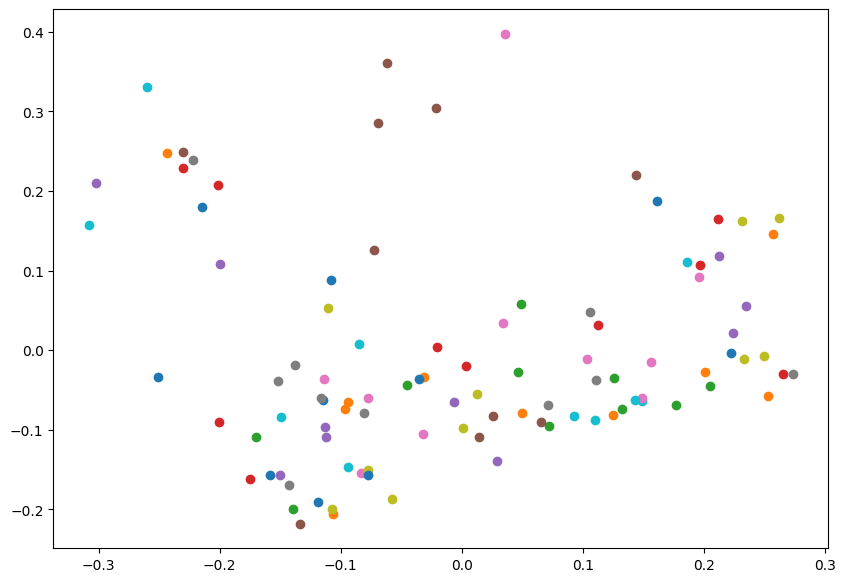

In [13]:
# PCA visualization of video embeddings
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

embedding_matrix = np.array(list(embedding_dict.values()))
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embedding_matrix)
plt.figure(figsize=(10, 7))
for i, video_name in enumerate(embedding_dict.keys()):
    plt.scatter(reduced_embeddings[i, 0], reduced_embeddings[i, 1], label=video_name)
# plt.title("PCA of Video Embeddings")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.legend()
plt.show()

In [7]:
video_dir = "/Users/sydneyhan/Desktop/src/ConstActLoc/data/reconstructed_videos"
# report all mpeg-4 video durations (min, max, mean, median)
# report all mpeg-4 video resolutions (min, max, mean, median)
durations = []
widths = []
heights = []
resolutions = []
video_paths = glob(os.path.join(video_dir, "*"))
for video_path in video_paths:
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    video_name = os.path.basename(video_path)
    start_sec = video_name.split("_")[1]
    end_sec = video_name.split("_")[2]
    duration = float(end_sec) - float(start_sec)+1
    #duration = frame_count / fps
    durations.append(duration)
    width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    resolutions.append((width, height))
    widths.append(width)
    heights.append(height)
print(f"Min duration: {min(durations)} seconds")
print(f"Max duration: {max(durations)} seconds")
print(f"Mean duration: {sum(durations) / len(durations)} seconds")
print(f"Median duration: {sorted(durations)[len(durations) // 2]} seconds")
print(f"Min resolution: {min(resolutions)}")
print(f"Max resolution: {max(resolutions)}")
print(f"Mean resolution: ({sum(widths) / len(widths)}, {sum(heights) / len(heights)})")
print(f"Median resolution: ({sorted(widths)[len(widths) // 2]}, {sorted(heights)[len(heights) // 2]})")
print(f"Min width: {min(widths)}")
print(f"Max width: {max(widths)}")
print(f"Mean width: {sum(widths) / len(widths)}")
print(f"Median width: {sorted(widths)[len(widths) // 2]}")
print(f"Min height: {min(heights)}")
print(f"Max height: {max(heights)}")
print(f"Mean height: {sum(heights) / len(heights)}")
print(f"Median height: {sorted(heights)[len(heights) // 2]}")

Min duration: 5.0 seconds
Max duration: 241.0 seconds
Mean duration: 44.46 seconds
Median duration: 31.0 seconds
Min resolution: (202.0, 360.0)
Max resolution: (3840.0, 2160.0)
Mean resolution: (1284.7, 931.7)
Median resolution: (1280.0, 720.0)
Min width: 202.0
Max width: 3840.0
Mean width: 1284.7
Median width: 1280.0
Min height: 360.0
Max height: 3840.0
Mean height: 931.7
Median height: 720.0


In [ ]:
# gemini_path = "output/inference_results_gemini-3.1-pro-preview_videos.json"
gemini_path = "output/inference_results_gemini-3.1-flash-lite-preview_videos.json"
gpt_path = "output/inference_results_gpt-5.4.json"
# out_path = "output/inference_results_gemini-3.1-pro-preview_video_gpt_format.json"
out_path = "output/inference_results_gemini-3.1-flash-lite-preview_video_gpt_format.json"

def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def clean_path(p):
    return p.replace("\\", "/")

def video_key_from_video_path(video_path):
    return os.path.splitext(os.path.basename(clean_path(video_path)))[0]

def parse_frame_path(frame_path):
    base = os.path.basename(clean_path(frame_path))
    stem = os.path.splitext(base)[0]
    m = re.search(r"_(\d+)_(\d+)$", stem)
    if not m:
        raise ValueError(f"Cannot parse frame path: {frame_path}")
    video_key = stem[:m.start()]
    second = int(m.group(1))
    frame_idx = int(m.group(2))
    return video_key, second, frame_idx

def action_at_second(segments, second):
    # segments: [[action, start_second], ...]
    segments = sorted(segments, key=lambda x: int(x[1]))
    action = segments[0][0] if segments else "none"
    for seg_action, start in segments:
        if second >= int(start):
            action = seg_action
        else:
            break
    return action

gemini_rows = read_jsonl(gemini_path)
gpt_rows = read_jsonl(gpt_path)

gemini_by_key = {
    video_key_from_video_path(r["video_path"]): r
    for r in gemini_rows
}

gpt_by_key = defaultdict(list)
for r in gpt_rows:
    key, sec, frame_idx = parse_frame_path(r["frame_path"])
    rr = dict(r)
    rr["_video_key"] = key
    rr["_second"] = sec
    rr["_frame_idx"] = frame_idx
    gpt_by_key[key].append(rr)

converted = []
missing_keys = set()

for key, frames in gpt_by_key.items():
    gem = gemini_by_key.get(key)
    if gem is None:
        missing_keys.add(key)
        continue

    n = len(frames)
    per_frame_cost = gem.get("inference_cost", 0) / n if n > 0 else 0
    per_frame_time = gem.get("inference_time", 0) / n if n > 0 else 0

    for fr in sorted(frames, key=lambda x: (x["_second"], x["_frame_idx"])):
        converted.append({
            "frame_path": fr["frame_path"],
            "action": action_at_second(gem.get("segments", []), fr["_second"]),
            "inference_cost": per_frame_cost,
            "inference_time": per_frame_time,
        })

with open(out_path, "w", encoding="utf-8") as f:
    for row in converted:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

print("gemini videos:", len(gemini_rows))
print("gpt frames:", len(gpt_rows))
print("converted frames:", len(converted))
print("missing video keys:", len(missing_keys))
print(sorted(list(missing_keys))[:10])
print("output:", out_path)
print(converted[:3])


gemini videos: 100
gpt frames: 4309
converted frames: 4309
missing video keys: 0
[]
output: output/inference_results_gemini-3.1-flash-lite-preview_video_gpt_format.json
[{'frame_path': 'data/frames_fps1\\clipped_0_10_NYC_crane_and__rigging_rebar_bundles_team_safety_always_firstcomment_if_you_do_construction_0_17.jpg', 'action': 'none', 'inference_cost': 5.663888888888889e-05, 'inference_time': 0.3600966665479872}, {'frame_path': 'data/frames_fps1\\clipped_0_10_NYC_crane_and__rigging_rebar_bundles_team_safety_always_firstcomment_if_you_do_construction_1_47.jpg', 'action': 'none', 'inference_cost': 5.663888888888889e-05, 'inference_time': 0.3600966665479872}, {'frame_path': 'data/frames_fps1\\clipped_0_10_NYC_crane_and__rigging_rebar_bundles_team_safety_always_firstcomment_if_you_do_construction_2_77.jpg', 'action': 'attach rigging', 'inference_cost': 5.663888888888889e-05, 'inference_time': 0.3600966665479872}]


In [10]:
def parse_frame_filename(path):
    """
    예:
    clipped_0_9_broom_3_107.jpg

    video_id = clipped_0_9_broom
    second = 3
    frame_index = 107  # 무시
    """
    stem = Path(path).stem
    parts = stem.split("_")

    if len(parts) < 3:
        raise ValueError(f"Invalid filename: {path}")

    second = int(parts[-2])
    video_id = "_".join(parts[:-2])

    return video_id, second


def reconstruct_videos(
    frame_dir,
    output_dir="reconstructed_videos",
    fps=30,
    image_exts=("jpg", "jpeg", "png")
):
    frame_dir = Path(frame_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # 이미지 파일 수집
    frame_paths = []
    for ext in image_exts:
        frame_paths.extend(frame_dir.glob(f"*.{ext}"))

    if not frame_paths:
        raise ValueError("No frame images found.")

    # video_id별 그룹핑
    video_groups = defaultdict(list)

    for path in frame_paths:
        try:
            video_id, second = parse_frame_filename(path)
            video_groups[video_id].append((second, path))
        except Exception as e:
            print(f"Skipping {path.name}: {e}")

    # 비디오별 복원
    for video_id, frames in tqdm(video_groups.items(), desc="Reconstructing videos"):
        frames.sort(key=lambda x: x[0])

        first_img = cv2.imread(str(frames[0][1]))
        if first_img is None:
            print(f"Skipping video {video_id}: cannot read first image")
            continue

        h, w = first_img.shape[:2]
        output_path = output_dir / f"{video_id}.mp4"

        # 1초에 1프레임씩 재생
        save_fps = 1

        fourcc = cv2.VideoWriter_fourcc(*"avc1")
        writer = cv2.VideoWriter(str(output_path), fourcc, save_fps, (w, h))

        if not writer.isOpened():
            print("avc1 failed, trying mp4v...")
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
            writer = cv2.VideoWriter(str(output_path), fourcc, save_fps, (w, h))

        if not writer.isOpened():
            print(f"Failed to open writer: {output_path.resolve()}")
            continue
        
        for second, img_path in frames:
            img = cv2.imread(str(img_path))

            if img is None:
                print(f"Skipping unreadable image: {img_path}")
                continue

            if img.shape[:2] != (h, w):
                img = cv2.resize(img, (w, h))

            # 프레임 1장 = 영상 1초
            writer.write(img)

        writer.release()

# 사용 예시
reconstruct_videos(frame_dir="data/frames_fps1", output_dir="data/reconstructed_videos", fps=1)

Reconstructing videos:   1%|          | 1/100 [00:00<00:10,  9.73it/s]

avc1 failed, trying mp4v...
Failed to open writer: /Users/sydneyhan/Desktop/src/ConstActLoc/data/reconstructed_videos/clipped_0_91_Very fast roofer 430 min square full safety and bags.mp4


2026-05-23 10:46:45.166 python[93074:10107074] WARNING: -finishWriting should not be called on the main thread.
Reconstructing videos:   4%|▍         | 4/100 [00:04<01:53,  1.18s/it]OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
2026-05-23 10:46:50.217 python[93074:10107074] WARNING: -finishWriting should not be called on the main thread.
Reconstructing videos:  31%|███       | 31/100 [01:09<02:54,  2.52s/it]OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenC

In [11]:
# check how many mp4 files in the reconstructed_videos folder
reconstructed_videos = glob("data/reconstructed_videos/*.mp4")
print(f"Number of reconstructed videos: {len(reconstructed_videos)}")


Number of reconstructed videos: 100


In [3]:
import pandas as pd

# CSV 로드
df = pd.read_csv("data/GT_fully_annotated.csv")

# annotation 컬럼들
annotation_cols = ["action_1", "action_2", "action_3"]

# 실제 존재하는 컬럼만 사용 (혹시 일부 없을 경우 대비)
annotation_cols = [col for col in annotation_cols if col in df.columns]

# 모든 annotation 값을 한 줄로 펼치기
all_annotations = (
    df[annotation_cols]
    .stack()                  # 세 컬럼을 한 컬럼처럼 펼침
    .astype(str)
    .str.strip()             # 공백 제거
)

# 빈 문자열 / nan 제거
all_annotations = all_annotations[
    (all_annotations != "") &
    (all_annotations.str.lower() != "nan")
]

# 개수 집계
annotation_counts = all_annotations.value_counts()

# 결과 출력
print("=== Annotation 종류 및 개수 ===")
print(annotation_counts)

print(f"\n총 unique annotation 수: {annotation_counts.shape[0]}")

=== Annotation 종류 및 개수 ===
none                              1131
lift/carry window/sheets           411
drill                              370
lay brick/block                    336
plaster                            309
tie rebar                          295
apply adhesive                     205
install tiles                      194
install roofing sheets             164
lift/carry cement bags             158
climb/climb down ladders/steps     133
screed                             126
attach rigging                     105
drive compactor                     85
weld                                80
paint                               73
hammer                              67
drive vehicles                      66
push/pull cart                      55
measure dimensions/distances        48
shovel                              44
sweep                               25
cut tiles/woods                     25
measure the level                   24
lift hose                           1

In [4]:
df_pred = pd.read_json("output/inference_results_gpt-5.4.json", lines=True)

# 예측에 사용된 unique class 확인
unique_classes = (
    df_pred["action"]
    .dropna()
    .astype(str)
    .str.strip()
    .loc[lambda s: s != ""]
    .sort_values()
    .unique()
)

print("=== Unique predicted classes ===")
for cls in unique_classes:
    print(cls)

print(f"\n총 unique class 수: {len(unique_classes)}")

=== Unique predicted classes ===
apply adhesive
attach rigging
climb/climb down ladders/steps
cut tiles/woods
draw points/lines
drill
drive compactor
drive vehicles
hammer
install roofing sheets
install tiles
lay brick/block
lift hose
lift/carry cement bags
lift/carry window/sheets
measure dimensions/distances
measure the level
none
paint
plaster
push/pull cart
screed
shovel
sweep
tie rebar
weld

총 unique class 수: 26


In [5]:

import pickle
from pathlib import Path

# JSONL 로드
df_pred = pd.read_json("output/inference_results_gpt-5.4.json", lines=True)

# unique class 추출
unique_classes = (
    df_pred["action"]
    .dropna()
    .astype(str)
    .str.strip()
    .loc[lambda s: s != ""]
    .unique()
    .tolist()
)

# 저장 경로 생성
save_path = Path("data/action_classes.pkl")
save_path.parent.mkdir(parents=True, exist_ok=True)

# pkl 저장
with open(save_path, "wb") as f:
    pickle.dump(unique_classes, f)

print(f"Saved {len(unique_classes)} classes to {save_path}")

Saved 26 classes to data/action_classes.pkl


In [ ]:
agent = OpenAI(api_key=OPENAI_API_KEY)
model_name = "gpt-5.4"

In [ ]:
df_class_path = "data/action_classes.csv"
df_class = pd.read_csv(df_class_path)
action_classes = df_class["class"].tolist()
action_classes.append("none")

prompt = f"""
# ROLE:
You are an expert construction manager analyzing video frames from construction site videos.

# INSTRUCTION:
Determine the worker's current action from the provided frame or frames.

An action should be identified ONLY when the worker is actively performing a construction task through direct physical interaction with relevant work entities, such as:
- tools
- materials
- construction equipment
- building components

Direct physical interaction means the worker's hand(s) are visibly in contact with the object(s) involved in the task.

Return "none" in the following cases:
- the worker is preparing to start a task
- the worker is observing, waiting, or idle
- the worker's hands are not in active contact with relevant work objects
- the visible action does not clearly match any provided action options
- the worker is performing a non-target action outside the provided action list

Choose ONLY from the provided action options below:
{action_classes}

Be conservative. If the action is ambiguous or insufficiently visible, return "none".

# OUTPUT FORMAT:
Return a valid JSON object only.
Key: "action"
Value: One action from the provided choices or "none"

# EXAMPLE:
Input: A frame showing a worker using a hammer to drive a nail into a piece of wood
Output: "action": "hammer"
"""

class StructuredResponse(BaseModel):
    action: conlist(Literal[tuple(action_classes)], min_length=1, max_length=1)

In [ ]:
frame_path = "data/frames_fps1/clipped_0_11_cart_v1_8_214.jpg"
base64_frame = utils.encode_image(frame_path)

# response = agent.responses.create(
#     model=model_name,
#     input=[
#         {
#             "role": "user",
#             "content": [
#                 { "type": "input_text", "text": prompt },
#                 {
#                     "type": "input_image",
#                     "image_url": f"data:image/jpeg;base64,{base64_frame}",
#                     "detail": "auto"
#                 },
#             ],
#         }
#     ],
# )
response = agent.responses.parse(
    model=model_name,
    input=[
        {
            "role": "user",
            "content": [
                { "type": "input_text", "text": prompt },
                {
                    "type": "input_image",
                    "image_url": f"data:image/jpeg;base64,{base64_frame}",
                    "detail": "auto"
                },
            ],
        }
    ],
    text_format=StructuredResponse,
)

In [ ]:
agent = anthropic.Anthropic(api_key=CLAUDE_API_KEY)

In [ ]:
frame_path = "data/frames_fps1/clipped_0_11_cart_v1_8_214.jpg"
base64_frame = utils.encode_image(frame_path)
image_media_type = "image/jpeg"

In [ ]:
# message = agent.messages.create(
message = agent.messages.parse(
    model="claude-sonnet-4-6",
    max_tokens=1024,
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "source": {
                        "type": "base64",
                        "media_type": image_media_type,
                        "data": base64_frame,
                    },
                },
                {"type": "text", "text": prompt},
            ],
        }
    ],
    output_format=StructuredResponse,
)
print(message)

In [ ]:
print(message.usage.input_tokens)
print(message.usage.output_tokens)
print(message.parsed_output.action[0])

In [40]:
import os
import json
import pandas as pd


input_jsonl = "output/inference_results_gpt-5.4.json"
output_csv = "output/inference_results_gpt-5.4.csv"

rows = []

with open(input_jsonl, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue

        item = json.loads(line)

        frame_path = item["frame_path"]
        action = item["action"]

        filename = os.path.basename(frame_path)
        filename_wo_ext = os.path.splitext(filename)[0]

        parts = filename_wo_ext.split("_")

        second = int(parts[-2])
        frame_idx = int(parts[-1])
        base_filename = "_".join(parts[:-2])

        rows.append({
            "base_filename": base_filename,
            "second": second,
            # "frame_idx": frame_idx,
            "action": action
        })

df = pd.DataFrame(rows)

df = df.sort_values(
    by=["base_filename", "second"],
    ascending=[True, True]
).reset_index(drop=True)

df.to_csv(output_csv, index=False)